## Define the Convolutional Neural Network

After you've looked at the data you're working with and, in this case, know the shapes of the images and of the keypoints, you are ready to define a convolutional neural network that can *learn* from this data.

In this notebook and in `models.py`, you will:
1. Define a CNN with images as input and keypoints as output
2. Construct the transformed FaceKeypointsDataset, just as before
3. Train the CNN on the training data, tracking loss
4. See how the trained model performs on test data
5. If necessary, modify the CNN structure and model hyperparameters, so that it performs *well* **\***

**\*** What does *well* mean?

"Well" means that the model's loss decreases during training **and**, when applied to test image data, the model produces keypoints that closely match the true keypoints of each face. And you'll see examples of this later in the notebook.

---


## CNN Architecture

Recall that CNN's are defined by a few types of layers:
* Convolutional layers
* Maxpooling layers
* Fully-connected layers

You are required to use the above layers and encouraged to add multiple convolutional layers and things like dropout layers that may prevent overfitting. You are also encouraged to look at literature on keypoint detection, such as [this paper](https://arxiv.org/pdf/1710.00977.pdf), to help you determine the structure of your network.


### TODO: Define your model in the provided file `models.py` file

This file is mostly empty but contains the expected name and some TODO's for creating your model.

---

## PyTorch Neural Nets

To define a neural network in PyTorch, you define the layers of a model in the function `__init__` and define the feedforward behavior of a network that employs those initialized layers in the function `forward`, which takes in an input image tensor, `x`. The structure of this Net class is shown below and left for you to fill in.

Note: During training, PyTorch will be able to perform backpropagation by keeping track of the network's feedforward behavior and using autograd to calculate the update to the weights in the network.

#### Define the Layers in ` __init__`
As a reminder, a conv/pool layer may be defined like this (in `__init__`):
```
# 1 input image channel (for grayscale images), 32 output channels/feature maps, 3x3 square convolution kernel
self.conv1 = nn.Conv2d(1, 32, 3)

# maxpool that uses a square window of kernel_size=2, stride=2
self.pool = nn.MaxPool2d(2, 2)      
```

#### Refer to Layers in `forward`
Then referred to in the `forward` function like this, in which the conv1 layer has a ReLu activation applied to it before maxpooling is applied:
```
x = self.pool(F.relu(self.conv1(x)))
```

Best practice is to place any layers whose weights will change during the training process in `__init__` and refer to them in the `forward` function; any layers or functions that always behave in the same way, such as a pre-defined activation function, should appear *only* in the `forward` function.

#### Why models.py

You are tasked with defining the network in the `models.py` file so that any models you define can be saved and loaded by name in different notebooks in this project directory. For example, by defining a CNN class called `Net` in `models.py`, you can then create that same architecture in this and other notebooks by simply importing the class and instantiating a model:
```
    from models import Net
    net = Net()
```

In [1]:
# load the data if you need to; if you have already loaded the data, you may comment this cell out
# -- DO NOT CHANGE THIS CELL -- #

import os
import requests
import zipfile

# Create a folder 'data/' in the current directory
folder_name = 'data'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# URL of the file to be downloaded
url = "https://s3.amazonaws.com/video.udacity-data.com/topher/2018/May/5aea1b91_train-test-data/train-test-data.zip"
file_name = 'train-test-data.zip'

# Download the content into the 'data/' folder
response = requests.get(url)
with open(file_name, 'wb') as file:
    file.write(response.content)

downloaded_file_path = os.path.abspath(file_name)
print(f"File downloaded to {downloaded_file_path}")
print(f"File name: {file_name}")


# Unzip the file
with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(folder_name)

print(f"Files extracted to {os.path.abspath(folder_name)}")

File downloaded to /workspace/home/train-test-data.zip
File name: train-test-data.zip
Files extracted to /workspace/home/data


In [2]:
# import the usual resources
import matplotlib.pyplot as plt
import numpy as np

# watch for any changes in model.py, if it changes, re-load it automatically
%load_ext autoreload
%autoreload 2

In [3]:
## TODO: Define the Net in models.py

import torch
import torch.nn as nn
import torch.nn.functional as F

# Check if GPU is available and set the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

## TODO: Once you've define the network, you can instantiate it
# one example conv layer has been provided for you
from models import Net

# Instantiate the network and move it to the device (GPU or CPU)
net = Net()
net.to(device)
print(net)

Using device: cuda
Net(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(2, 2), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=36864, out_features=1000, bias=True)
  (fc2): Linear(in_features=1000, out_features=1000, bias=True)
  (fc3): Linear(in_features=1000, out_features=136, bias=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (drop2): Dropout(p=0.3, inplace=False)
)


## Transform the dataset 

To prepare for training, create a transformed dataset of images and keypoints.

### TODO: Define a data transform

In PyTorch, a convolutional neural network expects a torch image of a consistent size as input. For efficient training, and so your model's loss does not blow up during training, it is also suggested that you normalize the input images and keypoints. The necessary transforms have been defined in `data_load.py` and you **do not** need to modify these; take a look at this file (you'll see the same transforms that were defined and applied in Notebook 1).

To define the data transform below, use a [composition](http://pytorch.org/tutorials/beginner/data_loading_tutorial.html#compose-transforms) of:
1. Rescaling and/or cropping the data, such that you are left with a square image (the suggested size is 224x224px)
2. Normalizing the images and keypoints; turning each RGB image into a grayscale image with a color range of [0, 1] and transforming the given keypoints into a range of [-1, 1]
3. Turning these images and keypoints into Tensors

These transformations have been defined in `data_load.py`, but it's up to you to call them and create a `data_transform` below. **This transform will be applied to the training data and, later, the test data**. It will change how you go about displaying these images and keypoints, but these steps are essential for efficient training.

As a note, should you want to perform data augmentation (which is optional in this project), and randomly rotate or shift these images, a square image size will be useful; rotating a 224x224 image by 90 degrees will result in the same shape of output.

In [4]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils

# the dataset we created in Notebook 1 is copied in the helper file `data_load.py`
from data_load import FacialKeypointsDataset
# the transforms we defined in Notebook 1 are in the helper file `data_load.py`
from data_load import Rescale, CenterCrop, RandomCrop, Normalize, ToTensor

## TODO: define the data_transform using transforms.Compose([all tx's, . , .])
# order matters! i.e. rescaling should come before a smaller crop
##data_transform = transforms.Compose([Rescale(250),
##                                     RandomCrop(224),
##                                     Normalize(),
##                                     ToTensor()])

data_transform_training = transforms.Compose([
    Rescale(250),
    RandomCrop(224),
    Normalize(),
    ToTensor()
])

# testing that you've defined a transform
assert(data_transform_training is not None), 'Define a data_transform_training'

In [5]:
# create the transformed dataset
transformed_dataset = FacialKeypointsDataset(csv_file='/workspace/data/training_frames_keypoints.csv',
                                             root_dir='/workspace/data/training/',
                                             transform=data_transform_training)


print('Number of images: ', len(transformed_dataset))

# iterate through the transformed dataset and print some stats about the first few samples
for i in range(4):
    sample = transformed_dataset[i]
    print(i, sample['image'].size(), sample['keypoints'].size())

Number of images:  3462
0 torch.Size([1, 224, 224]) torch.Size([68, 2])
1 torch.Size([1, 224, 224]) torch.Size([68, 2])
2 torch.Size([1, 224, 224]) torch.Size([68, 2])
3 torch.Size([1, 224, 224]) torch.Size([68, 2])


## Batching and loading data

Next, having defined the transformed dataset, we can use PyTorch's DataLoader class to load the training data in batches of whatever size as well as to shuffle the data for training the model. You can read more about the parameters of the DataLoader, in [this documentation](http://pytorch.org/docs/master/data.html).

#### Batch size
Decide on a good batch size for training your model. Try both small and large batch sizes and note how the loss decreases as the model trains. Too large a batch size may cause your model to crash and/or run out of memory while training.

**Note for Windows users**: Please change the `num_workers` to 0 or you may face some issues with your DataLoader failing.

In [6]:
# load training data in batches
batch_size = 10

train_loader = DataLoader(transformed_dataset, 
                          batch_size=batch_size,
                          shuffle=True, 
                          num_workers=0)

## Before training

Take a look at how this model performs before it trains. You should see that the keypoints it predicts start off in one spot and don't match the keypoints on a face at all! It's interesting to visualize this behavior so that you can compare it to the model after training and see how the model has improved.

#### Load in the test dataset

The test dataset is one that this model has *not* seen before, meaning it has not trained with these images. We'll load in this test data and before and after training, see how your model performs on this set!

To visualize this test data, we have to go through some un-transformation steps to turn our images into python images from tensors and to turn our keypoints back into a recognizable range. 

In [7]:
# load in the test data, using the dataset class
# AND apply the data_transform you defined above
##data_transform = transforms.Compose([Rescale(250),
##                                     RandomCrop(224),
##                                     Normalize(),
##                                     ToTensor()])

data_transform_testing = transforms.Compose([
    Rescale(250),
    CenterCrop(224),
    Normalize(),
    ToTensor()
])

# testing that you've defined a transform
assert(data_transform_testing is not None), 'Define a data_transform_testing'

# create the test dataset
test_dataset = FacialKeypointsDataset(csv_file='/workspace/data/test_frames_keypoints.csv',
                                             root_dir='/workspace/data/test/',
                                             transform=data_transform_testing)

In [8]:
# load test data in batches
batch_size = 10

test_loader = DataLoader(test_dataset, 
                          batch_size=batch_size,
                          shuffle=False, 
                          num_workers=0)

## Apply the model on a test sample

To test the model on a test sample of data, you have to follow these steps:
1. Extract the image and ground truth keypoints from a sample
2. Wrap the image in a Variable, so that the net can process it as input and track how it changes as the image moves through the network.
3. Make sure the image is a FloatTensor, which the model expects.
4. Forward pass the image through the net to get the predicted, output keypoints.

This function test how the network performs on the first batch of test data. It returns the images, the transformed images, the predicted keypoints (produced by the model), and the ground truth keypoints.

In [9]:
# test the model on a batch of test images

def net_sample_output():
    
    net.eval()
    
    # iterate through the test dataset
    for i, sample in enumerate(test_loader):
        
        # get sample data: images and ground truth keypoints
        images = sample['image'].to(device)
        key_pts = sample['keypoints'].to(device)

        # convert images to FloatTensors
        ## images = images.type(torch.cuda.FloatTensor)
        ## images = images.to(device).float()
        
        # forward pass to get net output
        with torch.no_grad():
            output_pts = net(images)
        
        # reshape to batch_size x 68 x 2 pts
        output_pts = output_pts.view(output_pts.size()[0], 68, -1)
        
        # break after first image is tested
        if i == 0:
            return images, output_pts, key_pts

#### Debugging tips

If you get a size or dimension error here, make sure that your network outputs the expected number of keypoints! Or if you get a Tensor type error, look into changing the above code that casts the data into float types: `images = images.type(torch.FloatTensor)`.

In [10]:
# call the above function
# returns: test images, test predicted keypoints, test ground truth keypoints
test_images, test_outputs, gt_pts = net_sample_output()

# print out the dimensions of the data to see if they make sense
print(test_images.data.size())
print(test_outputs.data.size())
print(gt_pts.size())

torch.Size([10, 1, 224, 224])
torch.Size([10, 68, 2])
torch.Size([10, 68, 2])


## Visualize the predicted keypoints

Once we've had the model produce some predicted output keypoints, we can visualize these points in a way that's similar to how we've displayed this data before, only this time, we have to "un-transform" the image/keypoint data to display it.

Note that I've defined a *new* function, `show_all_keypoints` that displays a grayscale image, its predicted keypoints and its ground truth keypoints (if provided).

In [11]:
def show_all_keypoints(image, predicted_key_pts, gt_pts=None):
    """Show image with predicted keypoints"""
    # image is grayscale
    plt.imshow(image, cmap='gray')
    plt.scatter(predicted_key_pts[:, 0], predicted_key_pts[:, 1], s=20, marker='.', c='m')
    # plot ground truth points as green pts
    if gt_pts is not None:
        plt.scatter(gt_pts[:, 0], gt_pts[:, 1], s=20, marker='.', c='g')


#### Un-transformation

Next, you'll see a helper function. `visualize_output` that takes in a batch of images, predicted keypoints, and ground truth keypoints and displays a set of those images and their true/predicted keypoints.

This function's main role is to take batches of image and keypoint data (the input and output of your CNN), and transform them into numpy images and un-normalized keypoints (x, y) for normal display. The un-transformation process turns keypoints and images into numpy arrays from Tensors *and* it undoes the keypoint normalization done in the Normalize() transform; it's assumed that you applied these transformations when you loaded your test data.

In [12]:
# visualize the output
# by default this shows a batch of 10 images

def visualize_output(test_images, test_outputs, gt_pts=None, batch_size=10):

    for i in range(batch_size):
        plt.figure(figsize=(20, 10))
        ax = plt.subplot(1, batch_size, i + 1)

        # Un-transform the image data
        image = test_images[i].detach().cpu().numpy()
        image = np.transpose(image, (1, 2, 0))

        # Un-transform the predicted keypoints
        predicted_key_pts = test_outputs[i].detach().cpu().numpy()

        # Undo normalization of predicted keypoints
        predicted_key_pts = predicted_key_pts * 50.0 + 100

        # Plot ground-truth keypoints for comparison
        ground_truth_pts = None

        if gt_pts is not None:
            ground_truth_pts = gt_pts[i].detach().cpu().numpy()
            ground_truth_pts = ground_truth_pts * 50.0 + 100

        # Show predicted and ground-truth keypoints
        show_all_keypoints(
            np.squeeze(image),
            predicted_key_pts,
            ground_truth_pts
        )

        plt.axis('off')

    plt.show()

## Training

#### Loss function
Training a network to predict keypoints is different than training a network to predict a class; instead of outputting a distribution of classes and using cross entropy loss, you may want to choose a loss function that is suited for regression, which directly compares a predicted value and target value. Read about the various kinds of loss functions (like MSE or L1/SmoothL1 loss) in [this documentation](http://pytorch.org/docs/master/_modules/torch/nn/modules/loss.html).

### TODO: Define the loss and optimization

Next, you'll define how the model will train by deciding on the loss function and optimizer.

---

In [13]:
## TODO: Define the loss and optimization
import torch.optim as optim

criterion = nn.MSELoss() ## nn.CrossEntropyLoss()

##optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
optimizer = optim.Adam(net.parameters(), lr=0.001)

## Training and Initial Observation

Now, you'll train on your batched training data from `train_loader` for a number of epochs. 

To quickly observe how your model is training and decide on whether or not you should modify it's structure or hyperparameters, you're encouraged to start off with just one or two epochs at first. As you train, note how your the model's loss behaves over time: does it decrease quickly at first and then slow down? Does it take a while to decrease in the first place? What happens if you change the batch size of your training data or modify your loss function? etc. 

Use these initial observations to make changes to your model and decide on the best architecture before you train for many epochs and create a final model.

In [14]:
def evaluate(loader):
    net.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for s in loader:
            im = s['image'].to(device).float()
            kp = s['keypoints'].to(device).float().view(s['keypoints'].size(0), -1)
            total += criterion(net(im), kp).item() * im.size(0); n += im.size(0)
    net.train()
    return total / n

In [15]:
def train_net(n_epochs):

    net.train()

    epoch_losses = []
    eval_losses = []

    for epoch in range(n_epochs):

        running_loss = 0.0
        epoch_loss = 0.0
        batch_count = 0

        for batch_i, data in enumerate(train_loader):

            images = data['image'].to(device).float()
            key_pts = data['keypoints'].to(device).float()

            key_pts = key_pts.view(key_pts.size(0), -1)

            output_pts = net(images)

            loss = criterion(output_pts, key_pts)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            epoch_loss += loss.item()
            batch_count += 1

            if batch_i % 10 == 9:
                print(
                    'Epoch: {}, Batch: {}, Avg. Loss: {}'.format(
                        epoch + 1,
                        batch_i + 1,
                        running_loss / 10
                    )
                )
                running_loss = 0.0
        
        avg_epoch_loss = epoch_loss / batch_count
        epoch_losses.append(avg_epoch_loss)
        
        eval_loss = evaluate(test_loader)
        eval_losses.append(eval_loss)
        
        '''
        print(
            f'Epoch {epoch + 1} completed - '
            f'Average Loss: {avg_epoch_loss:.4f}'
            f'Validation Loss: {eval_loss:.4f}'
        )
        '''
        print(
            f'Epoch {epoch + 1} completed - '
            f'Average Loss: {avg_epoch_loss:.4f} | '
            f'Validation Loss: {eval_loss:.4f}'
        )
        
    print('Finished Training')
    net.eval()

    return epoch_losses, eval_losses

In [16]:
# train your network
n_epochs = 20 # start small, and increase when you've decided on your model structure and hyperparams

# this is a Workspaces-specific context manager to keep the connection
# alive while training your model, not part of pytorch

epoch_losses, eval_losses = train_net(n_epochs)

Epoch: 1, Batch: 10, Avg. Loss: 0.29831682294607165
Epoch: 1, Batch: 20, Avg. Loss: 0.19760469645261763
Epoch: 1, Batch: 30, Avg. Loss: 0.2244061455130577
Epoch: 1, Batch: 40, Avg. Loss: 0.21917409747838973
Epoch: 1, Batch: 50, Avg. Loss: 0.18568361699581146
Epoch: 1, Batch: 60, Avg. Loss: 0.1780564844608307
Epoch: 1, Batch: 70, Avg. Loss: 0.20413158237934112
Epoch: 1, Batch: 80, Avg. Loss: 0.18173183128237724
Epoch: 1, Batch: 90, Avg. Loss: 0.18250709772109985
Epoch: 1, Batch: 100, Avg. Loss: 0.17822350114583968
Epoch: 1, Batch: 110, Avg. Loss: 0.1921399787068367
Epoch: 1, Batch: 120, Avg. Loss: 0.16148358955979347
Epoch: 1, Batch: 130, Avg. Loss: 0.17474640756845475
Epoch: 1, Batch: 140, Avg. Loss: 0.17690154910087585
Epoch: 1, Batch: 150, Avg. Loss: 0.25123570337891576
Epoch: 1, Batch: 160, Avg. Loss: 0.22698500752449036
Epoch: 1, Batch: 170, Avg. Loss: 0.18130044862627984
Epoch: 1, Batch: 180, Avg. Loss: 0.20154747739434242
Epoch: 1, Batch: 190, Avg. Loss: 0.22415872365236283
Epoch

Epoch: 5, Batch: 170, Avg. Loss: 0.16228534281253815
Epoch: 5, Batch: 180, Avg. Loss: 0.2096942752599716
Epoch: 5, Batch: 190, Avg. Loss: 0.17054741606116294
Epoch: 5, Batch: 200, Avg. Loss: 0.20993152186274527
Epoch: 5, Batch: 210, Avg. Loss: 0.201768858730793
Epoch: 5, Batch: 220, Avg. Loss: 0.22265995107591152
Epoch: 5, Batch: 230, Avg. Loss: 0.14218311309814452
Epoch: 5, Batch: 240, Avg. Loss: 0.20525808930397033
Epoch: 5, Batch: 250, Avg. Loss: 0.19753928631544113
Epoch: 5, Batch: 260, Avg. Loss: 0.21356700509786605
Epoch: 5, Batch: 270, Avg. Loss: 0.18583075255155562
Epoch: 5, Batch: 280, Avg. Loss: 0.20946204513311387
Epoch: 5, Batch: 290, Avg. Loss: 0.1963815212249756
Epoch: 5, Batch: 300, Avg. Loss: 0.16093349009752272
Epoch: 5, Batch: 310, Avg. Loss: 0.21779340952634813
Epoch: 5, Batch: 320, Avg. Loss: 0.1792615383863449
Epoch: 5, Batch: 330, Avg. Loss: 0.1994794562458992
Epoch: 5, Batch: 340, Avg. Loss: 0.19748373031616212
Epoch 5 completed - Average Loss: 0.1917 | Validatio

Epoch: 9, Batch: 330, Avg. Loss: 0.15387047678232194
Epoch: 9, Batch: 340, Avg. Loss: 0.17615402936935426
Epoch 9 completed - Average Loss: 0.1878 | Validation Loss: 0.0804
Epoch: 10, Batch: 10, Avg. Loss: 0.19896538257598878
Epoch: 10, Batch: 20, Avg. Loss: 0.29446583315730096
Epoch: 10, Batch: 30, Avg. Loss: 0.16959185972809793
Epoch: 10, Batch: 40, Avg. Loss: 0.19116487130522727
Epoch: 10, Batch: 50, Avg. Loss: 0.19664993286132812
Epoch: 10, Batch: 60, Avg. Loss: 0.1626523107290268
Epoch: 10, Batch: 70, Avg. Loss: 0.18515027239918708
Epoch: 10, Batch: 80, Avg. Loss: 0.1887357473373413
Epoch: 10, Batch: 90, Avg. Loss: 0.15491932183504104
Epoch: 10, Batch: 100, Avg. Loss: 0.19295370131731032
Epoch: 10, Batch: 110, Avg. Loss: 0.17919325679540635
Epoch: 10, Batch: 120, Avg. Loss: 0.19279110729694365
Epoch: 10, Batch: 130, Avg. Loss: 0.19030709713697433
Epoch: 10, Batch: 140, Avg. Loss: 0.18938904702663423
Epoch: 10, Batch: 150, Avg. Loss: 0.2090284802019596
Epoch: 10, Batch: 160, Avg. L

Epoch: 14, Batch: 110, Avg. Loss: 0.19972347393631934
Epoch: 14, Batch: 120, Avg. Loss: 0.13075431808829308
Epoch: 14, Batch: 130, Avg. Loss: 0.19807596355676652
Epoch: 14, Batch: 140, Avg. Loss: 0.21771088391542434
Epoch: 14, Batch: 150, Avg. Loss: 0.1734193541109562
Epoch: 14, Batch: 160, Avg. Loss: 0.1846513792872429
Epoch: 14, Batch: 170, Avg. Loss: 0.17844317182898523
Epoch: 14, Batch: 180, Avg. Loss: 0.1856938287615776
Epoch: 14, Batch: 190, Avg. Loss: 0.2623268663883209
Epoch: 14, Batch: 200, Avg. Loss: 0.14980618432164192
Epoch: 14, Batch: 210, Avg. Loss: 0.1787797786295414
Epoch: 14, Batch: 220, Avg. Loss: 0.17763175964355468
Epoch: 14, Batch: 230, Avg. Loss: 0.1937457077205181
Epoch: 14, Batch: 240, Avg. Loss: 0.21605276316404343
Epoch: 14, Batch: 250, Avg. Loss: 0.1613536350429058
Epoch: 14, Batch: 260, Avg. Loss: 0.16109377294778823
Epoch: 14, Batch: 270, Avg. Loss: 0.23608916625380516
Epoch: 14, Batch: 280, Avg. Loss: 0.197841589897871
Epoch: 14, Batch: 290, Avg. Loss: 0.1

Epoch: 18, Batch: 240, Avg. Loss: 0.21246160343289375
Epoch: 18, Batch: 250, Avg. Loss: 0.1428632877767086
Epoch: 18, Batch: 260, Avg. Loss: 0.1672780491411686
Epoch: 18, Batch: 270, Avg. Loss: 0.18724484071135522
Epoch: 18, Batch: 280, Avg. Loss: 0.2077190138399601
Epoch: 18, Batch: 290, Avg. Loss: 0.18838138580322267
Epoch: 18, Batch: 300, Avg. Loss: 0.1953557975590229
Epoch: 18, Batch: 310, Avg. Loss: 0.20006467252969742
Epoch: 18, Batch: 320, Avg. Loss: 0.1563588947057724
Epoch: 18, Batch: 330, Avg. Loss: 0.23210423141717912
Epoch: 18, Batch: 340, Avg. Loss: 0.2040640488266945
Epoch 18 completed - Average Loss: 0.1901 | Validation Loss: 0.0793
Epoch: 19, Batch: 10, Avg. Loss: 0.19446571320295333
Epoch: 19, Batch: 20, Avg. Loss: 0.20242310166358948
Epoch: 19, Batch: 30, Avg. Loss: 0.17414917498826982
Epoch: 19, Batch: 40, Avg. Loss: 0.13096504732966424
Epoch: 19, Batch: 50, Avg. Loss: 0.21582694053649903
Epoch: 19, Batch: 60, Avg. Loss: 0.17762503698468207
Epoch: 19, Batch: 70, Avg.

In [17]:
'''
plt.figure(figsize=(8,5))

plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')

plt.xlabel('Epoch')
plt.ylabel('Average Training Loss')
plt.title('Training Loss vs Epoch')
plt.xticks(range(1, len(epoch_losses) + 1))
plt.grid(True)

plt.show()
'''

"\nplt.figure(figsize=(8,5))\n\nplt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')\n\nplt.xlabel('Epoch')\nplt.ylabel('Average Training Loss')\nplt.title('Training Loss vs Epoch')\nplt.xticks(range(1, len(epoch_losses) + 1))\nplt.grid(True)\n\nplt.show()\n"

In [18]:
'''
plt.figure(figsize=(8,5))

plt.plot(range(1, len(eval_losses) + 1), eval_losses, marker='o')

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss vs Epoch')
plt.xticks(range(1, len(epoch_losses) + 1))
plt.grid(True)

plt.show()
'''

"\nplt.figure(figsize=(8,5))\n\nplt.plot(range(1, len(eval_losses) + 1), eval_losses, marker='o')\n\nplt.xlabel('Epoch')\nplt.ylabel('Validation Loss')\nplt.title('Validation Loss vs Epoch')\nplt.xticks(range(1, len(epoch_losses) + 1))\nplt.grid(True)\n\nplt.show()\n"

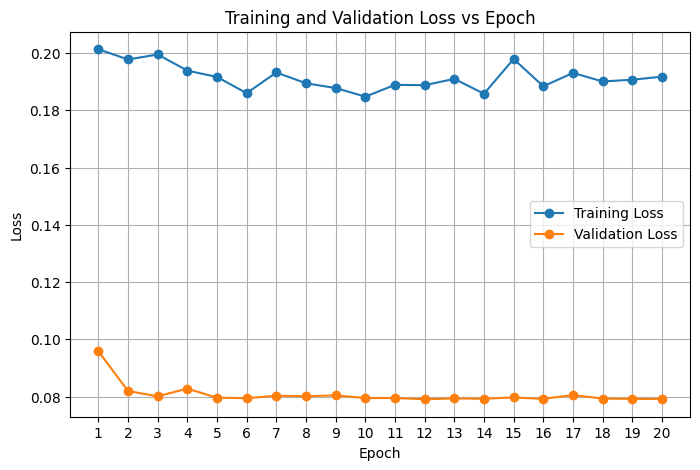

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(epoch_losses) + 1),
    epoch_losses,
    marker='o',
    label='Training Loss'
)

plt.plot(
    range(1, len(eval_losses) + 1),
    eval_losses,
    marker='o',
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss vs Epoch')

plt.xticks(range(1, len(epoch_losses) + 1))
plt.legend()
plt.grid(True)

plt.show()

## Test data

See how your model performs on previously unseen, test data. We've already loaded and transformed this data, similar to the training data. Next, run your trained model on these images to see what kind of keypoints are produced. You should be able to see if your model is fitting each new face it sees, if the points are distributed randomly, or if the points have actually overfitted the training data and do not generalize.

In [20]:
# get a sample of test data again
test_images, test_outputs, gt_pts = net_sample_output()

print(test_images.data.size())
print(test_outputs.data.size())
print(gt_pts.size())

torch.Size([10, 1, 224, 224])
torch.Size([10, 68, 2])
torch.Size([10, 68, 2])


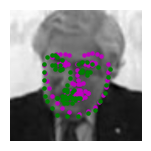

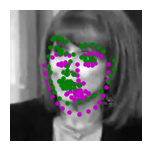

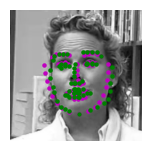

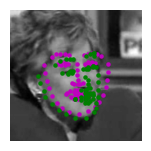

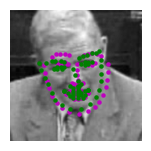

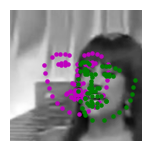

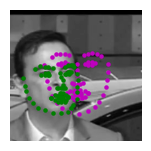

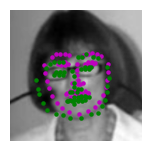

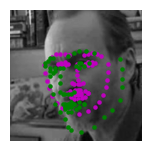

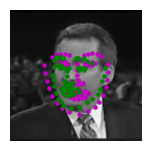

In [21]:
## TODO: visualize your test output
# you can use the same function as before, by un-commenting the line below:

# visualize_output(test_images, test_outputs, gt_pts)
visualize_output(test_images, test_outputs, gt_pts)

In [22]:
# Calculate the Euclidean distance between
# predicted and ground-truth keypoints

import torch

distance = torch.sqrt(
    ((test_outputs - gt_pts) ** 2).sum(dim=2)
)

print("Mean keypoint distance:", distance.mean().item())
print("Minimum keypoint distance:", distance.min().item())
print("Maximum keypoint distance:", distance.max().item())

Mean keypoint distance: 0.3722311008147049
Minimum keypoint distance: 0.0020670339111940246
Maximum keypoint distance: 1.231782249186883


In [23]:
print("Predicted keypoints:")
print("  Min:", test_outputs.min().item())
print("  Max:", test_outputs.max().item())
print("  Mean:", test_outputs.mean().item())

print("\nGround-truth keypoints:")
print("  Min:", gt_pts.min().item())
print("  Max:", gt_pts.max().item())
print("  Mean:", gt_pts.mean().item())

Predicted keypoints:
  Min: -0.8384428024291992
  Max: 1.5497850179672241
  Mean: 0.3387335240840912

Ground-truth keypoints:
  Min: -1.5675555555555556
  Max: 2.2637988826815647
  Mean: 0.34838560549248454


Once you've found a good model (or two), save your model so you can load it and use it later!

Save your models but please **delete any checkpoints and saved models before you submit your project** otherwise your workspace may be too large to submit.

In [24]:
## TODO: change the name to something uniqe for each new model
model_dir = 'saved_models/'
model_name = 'keypoints_model_5.pt'

# after training, save your model parameters in the dir 'saved_models'
torch.save(net.state_dict(), model_dir+model_name)

After you've trained a well-performing model, answer the following questions so that we have some insight into your training and architecture selection process. Answering all questions is required to pass this project.

### Question 1: What optimization and loss functions did you choose and why?


**Answer**: 

I used Mean Squared Error (MSE) loss (nn.MSELoss()) because facial keypoint detection is a regression problem where the model predicts continuous (x, y) coordinates for each of the 68 facial keypoints. MSE measures the squared difference between the predicted and ground-truth keypoint coordinates and is therefore appropriate for this task.

For optimization, I used Adam optimizer with a learning rate of 0.001:
    criterion = nn.MSELoss()
    optimizer = optim.Adam(net.parameters(), lr=0.001)

### Question 2: What kind of network architecture did you start with and how did it change as you tried different architectures? Did you decide to add more convolutional layers or any layers to avoid overfitting the data?

**Answer**: 

I initially started with a simpler architecture containing two convolutional layers followed by a fully connected layer. As I experimented with the architecture, I increased its capacity to better learn the facial features required for keypoint detection.

The final architecture contains four convolutional layers and three fully connected layers. The convolutional layers progressively increase the number of feature maps from 32 to 256, allowing the network to learn increasingly complex facial features.

In the fully connected part, I reduced the number of features progressively from 1000 → 1000 → 136, where the final 136 outputs represent the (x, y) coordinates of 68 facial keypoints.

I also incorporated dropout layers with different dropout probabilities to help reduce overfitting and improve the model's ability to generalize to unseen images.

### Question 3: How did you decide on the number of epochs and batch_size to train your model?

**Answer**: 

I used a batch size of 10, which was also used during the initial experiments and provided a practical balance between training speed and memory usage.

For the number of epochs, I experimented with different values, initially testing shorter training runs such as 1 and 5 epochs. 

I then increased the training duration to 10 epochs and monitored the average training loss after each epoch. The loss decreased substantially approx 0.18 at epoch no 6 and stabilized to 0.19 at epoch no 10. 

Finally I tried with 20 epochs. The loss went down around 0.186 at epoch 8, but it was oscillating up and down from, epoch 11 till 18 and came down to 0.188 at epoch 20. The best loss was at epoch 13 - 0.1802. 

## Feature Visualization

Sometimes, neural networks are thought of as a black box, given some input, they learn to produce some output. CNN's are actually learning to recognize a variety of spatial patterns and you can visualize what each convolutional layer has been trained to recognize by looking at the weights that make up each convolutional kernel and applying those one at a time to a sample image. This technique is called feature visualization and it's useful for understanding the inner workings of a CNN.

In the cell below, you can see how to extract a single filter (by index) from your first convolutional layer. The filter should appear as a grayscale grid.

[[-0.0731308   0.08269823 -0.07164269  0.16188735  0.0301187 ]
 [ 0.11697865  0.17755222  0.15736105 -0.03177207  0.04223436]
 [-0.20120211  0.17798431  0.13083683  0.03023333 -0.12555426]
 [ 0.08452237  0.01535688  0.12705497 -0.19097371 -0.14384915]
 [ 0.11496562 -0.05453992 -0.19802947 -0.18575275 -0.13657996]]
(5, 5)


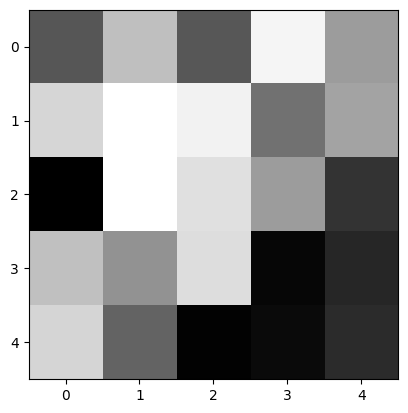

In [25]:
# Get the weights in the first conv layer, "conv1"
# if necessary, change this to reflect the name of your first conv layer
weights1 = net.conv1.weight.data.cpu()

w = weights1.numpy()

filter_index = 0

print(w[filter_index][0])
print(w[filter_index][0].shape)

# display the filter weights
plt.imshow(w[filter_index][0], cmap='gray')

## Feature maps

Each CNN has at least one convolutional layer that is composed of stacked filters (also known as convolutional kernels). As a CNN trains, it learns what weights to include in it's convolutional kernels and when these kernels are applied to some input image, they produce a set of **feature maps**. So, feature maps are just sets of filtered images; they are the images produced by applying a convolutional kernel to an input image. These maps show us the features that the different layers of the neural network learn to extract. For example, you might imagine a convolutional kernel that detects the vertical edges of a face or another one that detects the corners of eyes. You can see what kind of features each of these kernels detects by applying them to an image. One such example is shown below; from the way it brings out the lines in an the image, you might characterize this as an edge detection filter.

<img src='images/feature_map_ex.png' width=50% height=50%/>


Next, choose a test image and filter it with one of the convolutional kernels in your trained CNN; look at the filtered output to get an idea what that particular kernel detects.

### TODO: Filter an image to see the effect of a convolutional kernel
---

In [26]:
##TODO: load in and display any image from the transformed test dataset
net = Net()
net.load_state_dict(torch.load('saved_models/keypoints_model_5.pt'))
print(net)

Net(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(2, 2), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=36864, out_features=1000, bias=True)
  (fc2): Linear(in_features=1000, out_features=1000, bias=True)
  (fc3): Linear(in_features=1000, out_features=136, bias=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (drop2): Dropout(p=0.3, inplace=False)
)


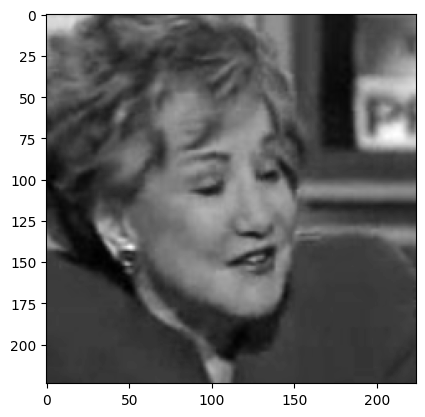

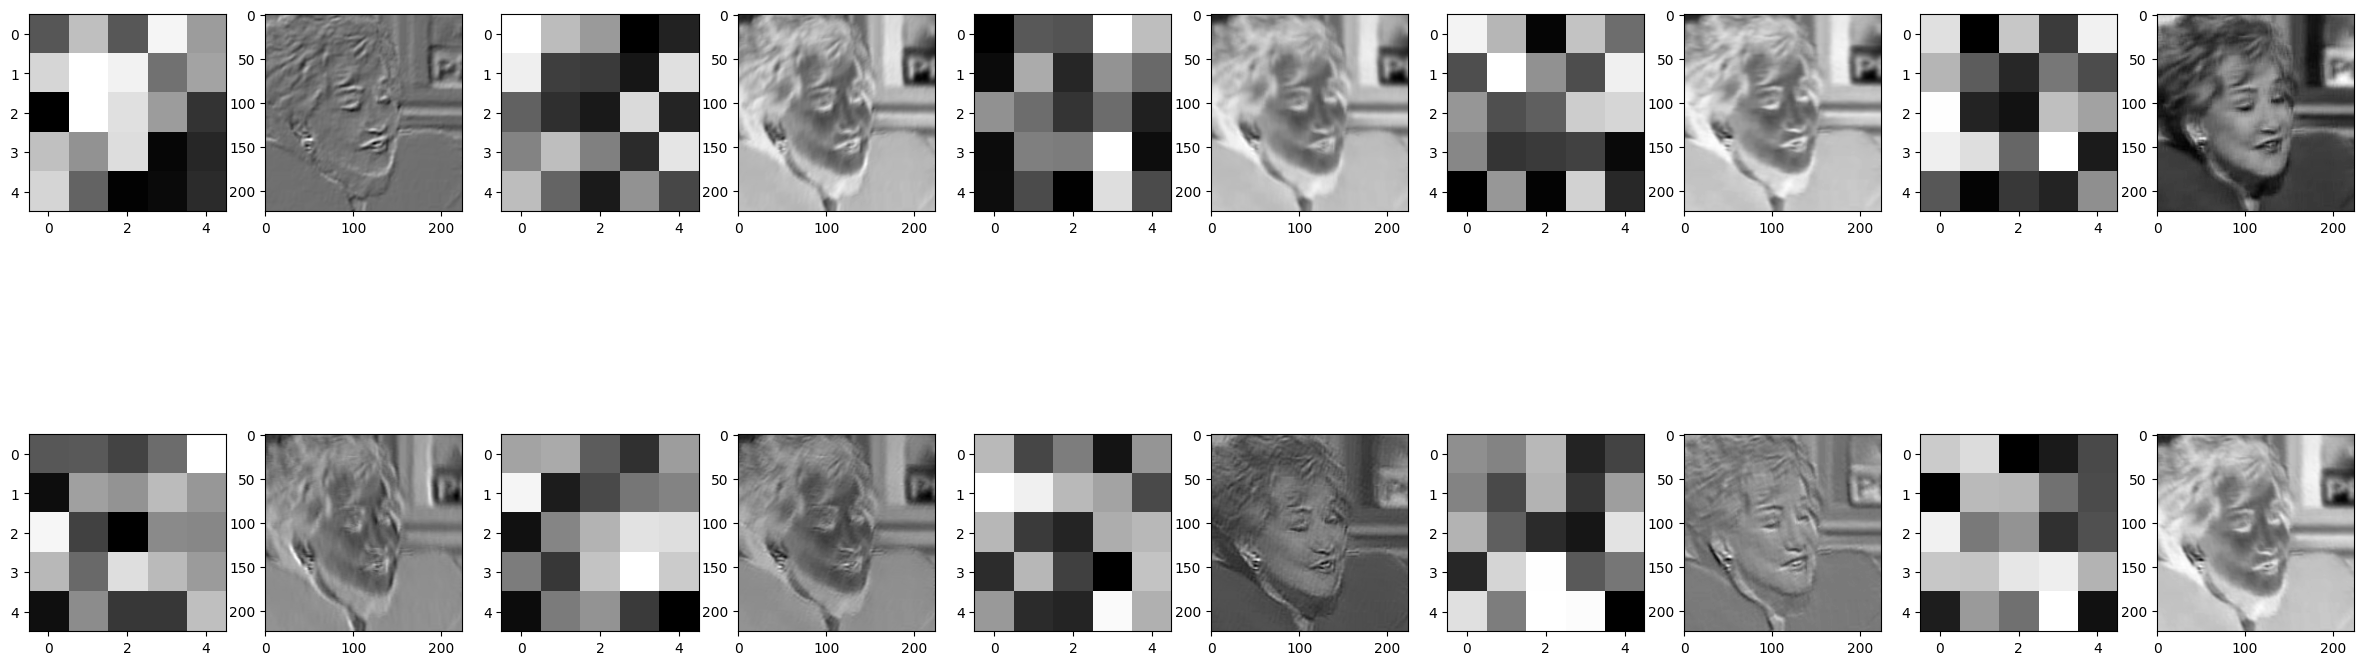

In [27]:
dataiter = iter(test_loader)
sample = next(dataiter)

images = sample['image']
keypoints = sample['keypoints']

images = images.numpy()

# select an image by index
idx = 3
img = np.squeeze(images[idx])

# Use OpenCV's filter2D function 
# apply a specific set of filter weights (like the one's displayed above) to the test image
import cv2
plt.imshow(img, cmap='gray')

weights = net.conv1.weight.data
w = weights.numpy()

# 1. first conv layer
# for 10 filters
fig=plt.figure(figsize=(30, 10))
columns = 5*2
rows = 2
for i in range(0, columns*rows):
    fig.add_subplot(rows, columns, i+1)
    if ((i%2)==0):
        plt.imshow(w[int(i/2)][0], cmap='gray')
    else:
        c = cv2.filter2D(img, -1, w[int((i-1)/2)][0])
        plt.imshow(c, cmap='gray')
plt.show()

### Question 4: Choose one filter from your trained CNN and apply it to a test image; what purpose do you think it plays? What kind of feature do you think it detects?


**Answer**: 

The selected filter appears to detect edges and changes in intensity, particularly horizontal and vertical edge patterns in the image. These edges can correspond to important facial structures such as the boundaries of the eyes, nose, mouth, and face.

The filtered images sometimes appear blurred or very bright/dark because the convolution filter responds differently depending on the local intensity patterns in the image. A strong response indicates that the corresponding feature is present in that region.

Since this filter belongs to the first convolutional layer, it is likely learning relatively simple, low-level features such as edges and intensity transitions rather than complex facial features.

In [28]:
net = net.to(device)

In [29]:
print("Model device:", next(net.parameters()).device)
print("Selected device:", device)

Model device: cuda:0
Selected device: cuda


In [30]:
#### Let us check test performance

net.eval()

test_loss = 0.0
total_samples = 0

with torch.no_grad():
    for sample in test_loader:

        images = sample['image'].to(device).float()
        key_pts = sample['keypoints'].to(device).float()

        outputs = net(images)

        # [batch_size, 136] → [batch_size, 68, 2]
        outputs = outputs.view(outputs.size(0), 68, 2)

        loss = criterion(outputs, key_pts)

        test_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

test_loss /= total_samples

print(f"Test MSE Loss: {test_loss:.4f}")

Test MSE Loss: 0.0792


#### Points to note:

Training loss: stabilized around epochs 11–20 with value 0.185 - 0.190
Test MSE Loss: 0.0796

#### Summary: 
What the 20-epoch experiment shows

Your curves are approximately:

Training loss: starts around 0.202, falls to about 0.185 by epoch 6, then fluctuates around 0.19.
Validation loss: starts around 0.096, drops rapidly to about 0.080–0.083, and then remains essentially flat.

The important observation is: The reduced dropout improved the training behavior, but it did not produce a meaningful improvement in validation performance. 

The validation curve is basically:

0.096
 ↓
0.082
 ↓
0.080
 ↔ ~0.080
 
from roughly epoch 3 onward.

Test further with Adam learning rate = 1e-4.

---
## Moving on!

Now that you've defined and trained your model (and saved the best model), you are ready to move on to the last notebook, which combines a face detector with your saved model to create a facial keypoint detection system that can predict the keypoints on *any* face in an image!